In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.spatial import cKDTree
import time

from clim_functions import compute_AR_from_Q


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


Cleaning.
1. Valid data for both inner- and outer-core data i.e. .dropna()
2. Cyclonicity must match
3. Reasonable values i.e. (Rc <= 300, |w| <= 1e-3)
4. detQ = 1
5. DOPPIO center must be reasonably close to nencioli center

In [3]:
fp = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_DOPPIO_SEACOFS_26yr.pkl'
df_doppio = pd.read_pickle(fp)
df_doppio['w'] *= 1e-3; #df_doppio['Omega0'] *= 1e-3; df_doppio['Omega'] *= 1e-3
df_doppio


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414944,10650,10641,349.0,158.0,AE,348.639821,156.731941,0.000030,"[[1.4645774777137426, -0.1681457560425603], [-...",0.013843,0.010961,118.891449,-77.470619,43.106056
414945,10650,10641,973.0,126.0,CE,981.263303,128.903719,-0.000003,"[[0.3331432297976212, 0.22917891709183946], [0...",-0.000959,-0.001517,55.056225,2.299476,24.775338
414946,10650,10641,805.0,95.0,AE,805.224646,95.090287,0.000010,"[[1.458787846536923, 0.38837617534635543], [0....",0.004449,0.005426,61.560240,-10.280739,45.893871
414947,10650,10641,157.0,34.0,CE,156.552258,33.561023,-0.000006,"[[1.1638016290142272, 0.659198284050232], [0.6...",-0.002711,-0.003349,95.216962,15.183481,33.510155


In [4]:
# --- 1. Drop only required columns ---
df_clean1 = df_doppio.dropna().copy()

print(f'1. Removed {len(df_doppio) - len(df_clean1)} eddy-days')

# --- 2. Cyclonicity match ---
nenc_cyc = np.where(df_clean1['nCyc'].values == 'AE', 1, -1)
doppio_cyc = np.sign(df_clean1['w'].values)

mask = (nenc_cyc == doppio_cyc)
df_clean2 = df_clean1.loc[mask].copy()

print(f'2. Removed {len(df_clean1) - len(df_clean2)} eddy-days')

# --- 3. Extract Q ONCE ---
df_clean2['AR'] = compute_AR_from_Q(np.stack(df_clean2['Q'].values))

# --- detQ (vectorised) ---
detQ = df_clean2['Q'].apply(lambda Q: Q[0,0]*Q[1,1] - Q[1,0]**2)

# --- masks ---
realistic_mask = (
    (df_clean2['Rc'].values < 300)
    & (np.abs(df_clean2['w'].values) < 1e-3)
    & (np.abs(df_clean2['AR']) < 8)
)

boundary_mask = (
    (df_clean2['xc'].values > 0)
    & (df_clean2['xc'].values < X_grid.max())
    & (df_clean2['yc'].values > 0)
    & (df_clean2['yc'].values < Y_grid.max())
)

det_mask = np.isclose(detQ, 1, atol=1e-5)

# --- center error ---
err = np.hypot(
    df_clean2['xc'].values - df_clean2['nxc'].values,
    df_clean2['yc'].values - df_clean2['nyc'].values
)
center_mask = err < 20

# --- combine everything at once (faster & cleaner) ---
final_mask = realistic_mask & boundary_mask & det_mask & center_mask

df_clean = df_clean2.loc[final_mask].copy().reset_index(drop=True)

print(f'Total removed: {len(df_clean2) - len(df_clean)} eddy-days')


1. Removed 96751 eddy-days
2. Removed 756 eddy-days
Total removed: 36584 eddy-days


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507,1.467389
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382,1.645935
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410,1.886162
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374,1.229757
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066,1.460876


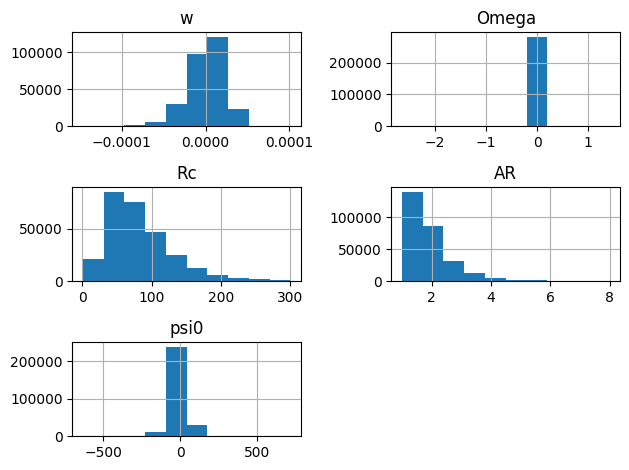

In [5]:
df_clean.hist(['w', 'Omega', 'Rc', 'AR', 'psi0'])
plt.tight_layout()
df_clean.head()


In [25]:
df_clean[df_clean.Day==1500]

,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR
1128,1500,1491,894.0,1464.0,AE,887.712239,1464.063902,0.000012,"[[0.5817854460240146, 0.44654490688543125], [0...",0.004352,0.003294,101.533041,-16.978902,38.262099,2.185896
1129,1500,1491,823.0,1448.0,AE,837.857597,1446.722931,0.000005,"[[0.553590152715263, 0.06586525209887555], [0....",0.002245,0.003556,103.711784,-19.123364,20.994530,1.817659
1130,1500,1491,384.0,1401.0,CE,382.761989,1401.509241,-0.000033,"[[0.6605705194729231, 0.38989334061776987], [0...",-0.013558,-0.010118,105.584854,56.401050,57.464886,1.869697
1131,1500,1491,223.0,1370.0,AE,222.612816,1369.082786,0.000027,"[[2.4090311337809234, -0.39112057140212847], [...",0.009307,0.012150,86.158939,-45.095133,41.077054,2.485265
1132,1500,1491,779.0,1277.0,CE,777.315375,1278.031392,-0.000019,"[[0.6621670144352586, -0.35513262231314024], [...",-0.008058,-0.008649,90.452501,35.381140,53.397334,1.810487
1133,1500,1491,877.0,1165.0,CE,877.166535,1163.109006,-0.000018,"[[1.327763260215565, 0.7481163077736027], [0.7...",-0.007269,-0.006400,96.579075,29.849865,63.865292,2.003237
1134,1500,1491,774.0,1069.0,AE,775.176485,1069.901861,0.000020,"[[1.6692359202752842, -0.03103566686633841], [...",0.008728,0.008728,84.285824,-31.001839,37.741600,1.670136
1135,1500,1491,576.0,1066.0,CE,575.527810,1065.085990,-0.000028,"[[3.0924811942621844, -0.39947622683283546], [...",-0.008207,-0.007697,104.142726,41.738261,43.370654,3.149988
1136,1500,1491,385.0,1040.0,AE,384.410343,1039.141547,0.000029,"[[1.3503924846997237, -0.12058896894938925], [...",0.013580,0.009084,237.844672,-256.944037,98.032075,1.373754
1137,1500,1491,891.0,978.0,AE,890.478661,976.267528,0.000015,"[[1.0891827242887133, -0.47684340234808964], [...",0.006594,0.003859,102.547234,-20.292557,46.470268,1.585248


In [6]:
# data = df_clean.iloc[14000]

# r = 150
# fnumber = f'{data.fnumber:05}'
# u_raw = np.load('/srv/scratch/z5297792/Climatology/u_v/u_' + fnumber + '.npy')
# v_raw = np.load('/srv/scratch/z5297792/Climatology/u_v/v_' + fnumber + '.npy')
# u_raw = np.where(np.abs(u_raw) > 1e30, np.nan, u_raw).astype(float)
# v_raw = np.where(np.abs(v_raw) > 1e30, np.nan, v_raw).astype(float)
# fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{data.fnumber:05}.nc'
# with nc.Dataset(fname) as dataset:
#     ocean_time = dataset.variables['ocean_time'][:].data / 86400
# t_rel = np.where(ocean_time == data.Day)[0][0]
# u_t, v_t = u_raw[:, :, :, t_rel], v_raw[:, :, :, t_rel]
# xc_surf, yc_surf = data.xc, data.yc
# ic = np.where(np.abs(x_grid-xc_surf)==np.min(np.abs(x_grid-xc_surf)))[0][0]
# jc = np.where(np.abs(y_grid-yc_surf)==np.min(np.abs(y_grid-yc_surf)))[0][0]
# x_mask = np.where(np.abs(x_grid - xc_surf) < r)[0]
# y_mask = np.where(np.abs(y_grid - yc_surf) < r)[0]
# X_mask, Y_mask = np.meshgrid(x_mask, y_mask)

# k = 0
# utk, vtk = u_t[:,:,k], v_t[:,:,k]
# plt.contourf(X_grid[X_mask, Y_mask], Y_grid[X_mask, Y_mask], np.hypot(utk[X_mask, Y_mask], vtk[X_mask, Y_mask]), cmap='Blues_r')
# spac = 3
# plt.quiver(X_grid[X_mask[::spac, ::spac], Y_mask[::spac, ::spac]], Y_grid[X_mask[::spac, ::spac], Y_mask[::spac, ::spac]],
#            utk[X_mask[::spac, ::spac], Y_mask[::spac, ::spac]], vtk[X_mask[::spac, ::spac], Y_mask[::spac, ::spac]])
# plt.scatter(data.nxc, data.nyc, marker='x', color='g')
# plt.scatter(data.xc, data.yc, marker='x', color='r', label='DOPPIO')
# dx_ell, dy_ell = X_grid[X_mask, Y_mask] - data.xc, Y_grid[X_mask, Y_mask] - data.yc
# rho2_ell = data.Q[0,0]*dx_ell**2 + 2*data.Q[1,0]*dx_ell*dy_ell + data.Q[1,1]*dy_ell**2 # rho^2
# plt.contour(X_grid[X_mask, Y_mask], Y_grid[X_mask, Y_mask], rho2_ell, levels=[data.Rc**2/2], colors='r' if data.nCyc=='AE' else 'c')
# plt.axis('equal')
# plt.legend()

# data


Tracking

In [12]:
df_data

,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507,1.467389
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382,1.645935
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410,1.886162
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374,1.229757
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066,1.460876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280853,10650,10641,860.0,180.0,CE,859.194829,180.306373,-0.000007,"[[0.6614053902780358, 0.4389834439185585], [0....",-0.003002,-0.003210,82.764188,10.994798,59.843014,1.952544
280854,10650,10641,349.0,158.0,AE,348.639821,156.731941,0.000030,"[[1.4645774777137426, -0.1681457560425603], [-...",0.013843,0.010961,118.891449,-77.470619,43.106056,1.500011
280855,10650,10641,973.0,126.0,CE,981.263303,128.903719,-0.000003,"[[0.3331432297976212, 0.22917891709183946], [0...",-0.000959,-0.001517,55.056225,2.299476,24.775338,3.177834
280856,10650,10641,805.0,95.0,AE,805.224646,95.090287,0.000010,"[[1.458787846536923, 0.38837617534635543], [0....",0.004449,0.005426,61.560240,-10.280739,45.893871,1.636702


In [15]:
df_data = df_clean.copy()
df_data = df_data.rename(columns={'nCyc': 'Cyc'})
start_day = df_data.Day.min()
end_day = df_data.Day.max()
df_data



,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507,1.467389
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382,1.645935
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410,1.886162
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374,1.229757
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066,1.460876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280853,10650,10641,860.0,180.0,CE,859.194829,180.306373,-0.000007,"[[0.6614053902780358, 0.4389834439185585], [0....",-0.003002,-0.003210,82.764188,10.994798,59.843014,1.952544
280854,10650,10641,349.0,158.0,AE,348.639821,156.731941,0.000030,"[[1.4645774777137426, -0.1681457560425603], [-...",0.013843,0.010961,118.891449,-77.470619,43.106056,1.500011
280855,10650,10641,973.0,126.0,CE,981.263303,128.903719,-0.000003,"[[0.3331432297976212, 0.22917891709183946], [0...",-0.000959,-0.001517,55.056225,2.299476,24.775338,3.177834
280856,10650,10641,805.0,95.0,AE,805.224646,95.090287,0.000010,"[[1.458787846536923, 0.38837617534635543], [0....",0.004449,0.005426,61.560240,-10.280739,45.893871,1.636702


In [19]:
start_ID = np.arange(len(df_data[df_data.Day==df_data.Day.min()]))
next_num = np.max(start_ID) + 1


In [20]:
start_ID, next_num

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37]),
 np.int64(38))

In [16]:
def tracking_kdtree(
    df_data,
    start_ID,
    next_num,
    L_SCALE=50,      # km
    W_SCALE=1e-5,    # s^-1
    R_THRESH=3,      # dimensionless
    LOOKBACK=4,
    K_NEIGH=5
):
    tic = time.perf_counter()
    df = df_data.copy()

    min_day = df['Day'].min()
    df['Eddy'] = -1
    df.loc[df['Day'] == min_day, 'Eddy'] = start_ID
    df['Eddy'] = df['Eddy'].astype('Int64')

    unique_days = np.sort(df['Day'].unique())

    daily_groups = {
        d: (
            df.loc[(df['Day'] == d) & df['xc'].notna()]
              .groupby('eddy_idx', as_index=False, sort=False)
              .first()
        )
        for d in unique_days
    }

    for day in unique_days[1:]:

        pres = daily_groups.get(day)
        if pres is None or len(pres) == 0:
            continue

        assigned = set()

        for _, pres_eddy in pres.iterrows():

            best_id = None
            best_R = np.inf

            for delta in range(1, LOOKBACK + 1):
                prev_day = day - delta
                prev = daily_groups.get(prev_day)

                if prev is None or len(prev) == 0:
                    continue

                prev = prev[prev['Eddy'].notna()]

                if len(prev) == 0:
                    continue

                coords = np.column_stack([
                    prev['xc'].values / L_SCALE,
                    prev['yc'].values / L_SCALE,
                    prev['w'].values / W_SCALE
                ])

                tree = cKDTree(coords)

                query = np.array([
                    pres_eddy['xc'] / L_SCALE,
                    pres_eddy['yc'] / L_SCALE,
                    pres_eddy['w'] / W_SCALE
                ])

                dist, idx = tree.query(query, k=min(K_NEIGH, len(prev)))

                dist = np.atleast_1d(dist)
                idx = np.atleast_1d(idx)

                for dR, j in zip(dist, idx):

                    prev_eddy = prev.iloc[j]

                    if (
                        dR < R_THRESH
                        and pres_eddy['Cyc'] == prev_eddy['Cyc']
                        and prev_eddy['Eddy'] not in assigned
                    ):
                        if dR < best_R:
                            best_R = dR
                            best_id = prev_eddy['Eddy']

                # prefer most recent valid match
                if best_id is not None:
                    break

            mask = (
                (df['Day'] == day)
                & (df['eddy_idx'] == pres_eddy['eddy_idx'])
            )

            if best_id is not None:
                df.loc[mask, 'Eddy'] = best_id
                assigned.add(best_id)
            else:
                df.loc[mask, 'Eddy'] = next_num
                assigned.add(next_num)
                next_num += 1

        if day % 200 == 0:
            print(f"Day {day}, elapsed: {time.perf_counter() - tic:.2f}s")

    assert not df.duplicated(subset=['Eddy', 'Day']).any(), \
        "Duplicate (Eddy, Day) pairs found!"

    df['next_num'] = next_num

    return df

    

In [22]:
df = df_data[df_data.Day <= 1464]

df_tracked = tracking_kdtree(
    df,
    start_ID=0,
    next_num=1,
    L_SCALE=50,
    W_SCALE=1e-5,
    R_THRESH=3,
    LOOKBACK=4
)


KeyError: 'Eddy_idx'

In [18]:
df_data.Day.unique()

array([ 1462,  1463,  1464, ..., 10648, 10649, 10650], shape=(9189,))